In [49]:
import rasterio as rio
import geopandas as gpd
from glob import glob
import matplotlib.pyplot as plt
from shapely.geometry import Point
import numpy as np
import seaborn as sns
import re
import os
import pandas as pd

In [14]:

LEGEND_CLASSES = {
    0: 'Nodata',
    1: 'Open Water',
    # 2: 'Impervious (raised structures)',
    2: 'Impervious Structures',
    # 3: 'Impervious (paved surfaces)',
    3: 'Impervious Surfaces',
    4: 'Barren Land',
    5: 'Tree Canopy/Woody Vegetation',
    6: 'Low Vegetation/Herbaceous',
    7: 'Cultivated Crops',
    8: 'Unclassified',
}

centroid_data = []
project_crs = None
histograms = {}
num_classes = 8

for split in range(4):
    histograms[split] = np.zeros(num_classes, dtype=np.int64)
    for path in glob(f'../data/splits/split_{split+1}/target/*.tif'):
        try:
            with rio.open(path) as src:
                if project_crs is None:
                    project_crs = src.crs

                bounds = src.bounds
                centroid_x = (bounds.left + bounds.right) / 2
                centroid_y = (bounds.bottom + bounds.top) / 2
                centroid_geom = Point(centroid_x, centroid_y)

                arr = src.read(1)
                if src.nodata is not None:
                    valid_mask = arr != src.nodata
                else:
                    # if nodata not defined, exclude zeros if 0==Nodata in your legend
                    valid_mask = arr != 0

                valid_pixels = arr[valid_mask].astype(np.int64)
            
                record = {
                    'split': split, 'source_file': path, 'geometry': centroid_geom,
                }
                
                raster_hist, _ = np.histogram(valid_pixels, bins=range(1, num_classes + 2))
                histograms[split] += raster_hist
                
                total_valid_pixels = np.sum(raster_hist)
    
                for i, count in enumerate(raster_hist):
                    class_id = i + 1
                    
                    # Get the descriptive name from your dictionary
                    class_name = LEGEND_CLASSES.get(class_id, f'Class_{class_id}')
                    
                    # Sanitize the name for use as a column header
                    # Replaces spaces and slashes with underscores
                    safe_col_name = re.sub(r'[\s/]+', '_', class_name)
                    
                    # Add data with the new descriptive name
                    # record[f'{safe_col_name}_ct'] = count
                    if total_valid_pixels > 0:
                        record[f'{safe_col_name}_pct'] = (count / total_valid_pixels) * 100
                    else:
                        record[f'{safe_col_name}_pct'] = 0

                centroid_data.append(record)

        except rio.errors.RasterioIOError as e:
            print(f"Error opening or reading {path}: {e}")
            continue

gdf = gpd.GeoDataFrame(centroid_data, crs=project_crs).to_crs(4326)
gdf.to_file('../data/sampling_sites/sampling_sites.shp')

C:\Users\dh2306\AppData\Local\Temp\ipykernel_33224\1162047254.py:75: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf.to_file('../data/sampling_sites/sampling_sites.shp')
c:\Users\dh2306\projects\ms-land-cover\.env\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'source_file' to 'source_fil'
  ogr_write(
c:\Users\dh2306\projects\ms-land-cover\.env\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'Open_Water_pct' to 'Open_Water'
  ogr_write(
c:\Users\dh2306\projects\ms-land-cover\.env\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'Impervious_Structures_pct' to 'Impervious'
  ogr_write(
c:\Users\dh2306\projects\ms-land-cover\.env\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'Impervious_Surfaces_pct' to 'Impervio_1'
  ogr_write(
c:\Users\dh2306\projects\ms-land-cover\.env\Lib

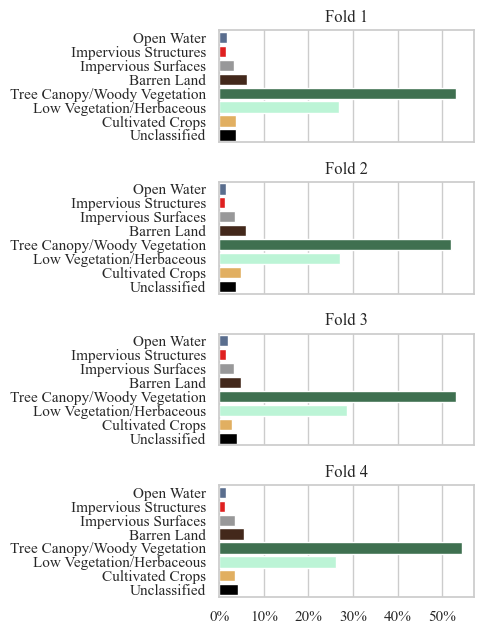

In [ ]:
import matplotlib.ticker as mticker # Import the ticker module


LEGEND_COLORS_HEX = {
    0: '#ffffff',
    1: '#516c97',
    # 2: '#989899',
    2: '#FF0000',
    # 3: '#ffffff',
    3: '#989899',
    4: '#4a2514',
    5: '#37784e',
    6: '#b3fdd6',
    7: '#f6b44c',
    8: '#000000',
}

sns.set_theme(style='whitegrid')
plt.rcParams['font.family'] = 'times new roman'

fig, axes = plt.subplots(4, 1, figsize=(5, 6.5), sharex=True, sharey=True)
class_labels = [v for k, v in LEGEND_CLASSES.items() if k != 0]
custom_colors = [LEGEND_COLORS_HEX[i] for i in range(1, 9)]

for i, ax in enumerate(axes.flatten()):
    sns.barplot(y=class_labels, x=(histograms[i] / histograms[i].sum()) * 100, ax=ax, palette=custom_colors, hue=class_labels)
    # ax.set_xscale('log')
    ax.xaxis.set_major_locator(mticker.FixedLocator([0, 10, 20, 30, 40, 50]))
    ax.xaxis.set_major_formatter(mticker.PercentFormatter())
    ax.set_title(f'Fold {i+1}')
    # ax.set_xlim(left=0.1, right=100)
    # ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
fig.tight_layout()
plt.savefig('../paper/images/fold_distributions.png', dpi=400)

C:\Users\dh2306\AppData\Local\Temp\ipykernel_33224\1806308776.py:154: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig2.tight_layout(pad=0.1)


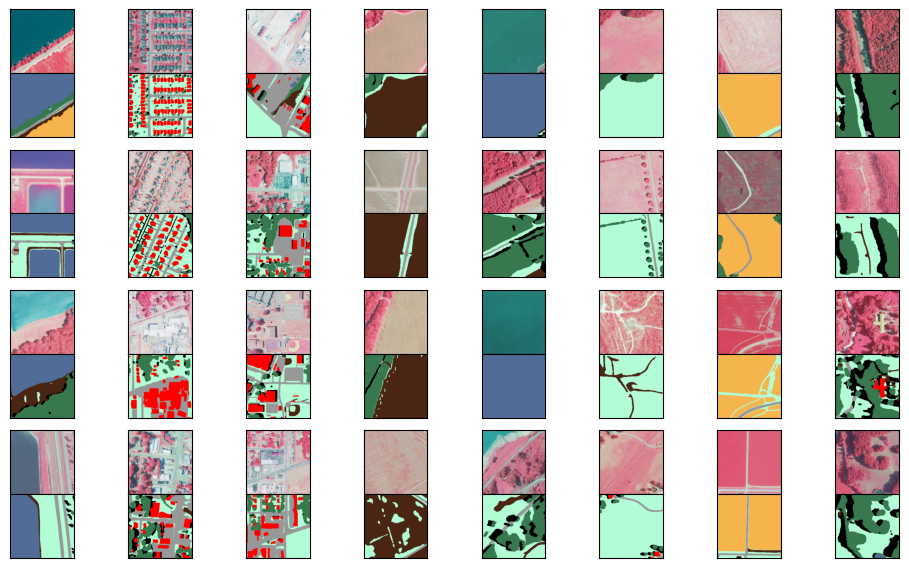

In [51]:
LEGEND_COLORS_HEX = {
    0: '#ffffff', 1: '#516c97', 2: '#FF0000', 3: '#989899',
    4: '#4a2514', 5: '#37784e', 6: '#b3fdd6', 7: '#f6b44c', 8: '#000000',
}

def hex_to_rgb(h):
    h = h.lstrip('#')
    return tuple(int(h[i:i+2], 16) for i in (0, 2, 4))

palette_rgb = {k: hex_to_rgb(v) for k, v in LEGEND_COLORS_HEX.items()}
max_lbl = max(palette_rgb.keys())

from rasterio.warp import reproject, Resampling

def colorize_labels(arr, palette, max_label):
    arr_safe = np.clip(arr, 0, max_label).astype(np.int64)
    cmap = np.zeros((max_label + 1, 3), dtype=np.uint8)
    for lbl, col in palette.items():
        if lbl <= max_label:
            cmap[lbl] = col
    return cmap[arr_safe]

def read_aligned_rgb_and_label(target_path, input_path, palette_rgb, max_lbl):
    with rio.open(target_path) as tgt:
        lbl = tgt.read(1)
        tgt_transform = tgt.transform
        tgt_crs = tgt.crs
        height, width = lbl.shape
        nodata = tgt.nodata

    if nodata is not None:
        lbl_safe = np.where(lbl == nodata, 0, lbl)
    else:
        lbl_safe = lbl
    color_lbl = colorize_labels(lbl_safe, palette_rgb, max_lbl).astype(np.uint8)

    if input_path is None or not os.path.exists(input_path):
        return lbl_safe, color_lbl, None

    with rio.open(input_path) as src_i:
        try:
            # prefer (4,1,2) if present (false color), else (1,2,3), else replicate single band
            if src_i.count >= 4:
                arr = src_i.read((4, 1, 2))
            elif src_i.count >= 3:
                arr = src_i.read((1, 2, 3))
            else:
                arr = np.repeat(src_i.read(1)[None, ...], 3, axis=0)
        except Exception:
            if src_i.count >= 3:
                arr = src_i.read((1, 2, 3))
            else:
                arr = np.repeat(src_i.read(1)[None, ...], 3, axis=0)

        img_disp = np.moveaxis(arr, 0, 2).astype('float32')
        if img_disp.max() > 1.1:
            img_disp = np.clip(img_disp, 0, 255) / 255.0
        else:
            img_disp = np.clip(img_disp, 0.0, 1.0)

    return lbl_safe, color_lbl, img_disp

# grid plotting: input above label; try several top candidates and skip tiles >= DOMINANCE_PCT
classes = [k for k in LEGEND_CLASSES.keys() if k != 0]
n_rows = 4
n_cols = len(classes)

# create the same sanitized names used when building centroid_data earlier
safe_names = {cid: re.sub(r'[\s/]+', '_', LEGEND_CLASSES[cid]) for cid in classes}

DOMINANCE_PCT = 90.0   # skip tiles with >= this percent for the class
MAX_CANDIDATES = 20    # check more top-ranked tiles for a non-dominated one

# tighter figure sizing for journal figure
fig2 = plt.figure(figsize=(n_cols * 1.2, n_rows * 1.4))
# smaller gap between rows (separate samples); within each sample stack input/label with no gap
gs = fig2.add_gridspec(n_rows, n_cols, hspace=0.10, wspace=0.02)

for split_idx in range(n_rows):
    split_df = gdf[gdf['split'] == split_idx].copy()
    for j, cid in enumerate(classes):
        subgs = gs[split_idx, j].subgridspec(2, 1, hspace=0.0)
        ax_top = fig2.add_subplot(subgs[0])   # input
        ax_bot = fig2.add_subplot(subgs[1])   # label

        pct_col = f"{safe_names[cid]}_pct"

        chosen_row = None
        # Primary approach: use the precomputed pct column if present
        if pct_col in split_df.columns and not split_df.empty:
            candidates = split_df.copy()
            candidates[pct_col] = pd.to_numeric(candidates.get(pct_col), errors='coerce')
            candidates = candidates.dropna(subset=[pct_col]).sort_values(pct_col, ascending=False).head(MAX_CANDIDATES)
            for _, row in candidates.iterrows():
                pct_val = row.get(pct_col)
                if pd.isna(pct_val):
                    continue
                if float(pct_val) < DOMINANCE_PCT:
                    chosen_row = row
                    break

        # Fallback: compute class percentage directly from label files (stop at first acceptable)
        if chosen_row is None and not split_df.empty:
            for _, row in split_df.iterrows():
                src_path = row['source_file']
                try:
                    with rio.open(src_path) as src_t:
                        lbl = src_t.read(1)
                        if src_t.nodata is not None:
                            valid_mask = lbl != src_t.nodata
                        else:
                            valid_mask = lbl != 0
                        total = int(np.count_nonzero(valid_mask))
                        if total == 0:
                            continue
                        class_count = int(np.count_nonzero(lbl[valid_mask] == cid))
                        pct = (class_count / total) * 100
                        if pct < DOMINANCE_PCT:
                            chosen_row = row
                            break
                except Exception:
                    # ignore file-read errors and continue to next candidate
                    continue

        # Plot chosen tile if found
        if chosen_row is not None:
            target_path = chosen_row['source_file']
            # robust input path resolution: try several common replacements and pick the first existing
            input_path = target_path
            try_paths = [
                target_path.replace(os.path.sep + 'target' + os.path.sep, os.path.sep + 'input' + os.path.sep),
                target_path.replace('/target/', '/input/'),
                target_path.replace('target', 'input')
            ]
            for p in try_paths:
                if p != target_path and os.path.exists(p):
                    input_path = p
                    break

            try:
                lbl_safe, color_lbl, img_disp = read_aligned_rgb_and_label(target_path, input_path, palette_rgb, max_lbl)
                if img_disp is not None:
                    ax_top.imshow(img_disp)
                ax_bot.imshow(color_lbl.astype('float32') / 255.0)
            except Exception:
                # on any read error leave blank (no text)
                pass
        # else leave blank (no text)

        ax_top.set_xticks([]); ax_top.set_yticks([])
        ax_bot.set_xticks([]); ax_bot.set_yticks([])

# minimize margins for a tight journal figure
fig2.tight_layout(pad=0.1)
fig2.subplots_adjust(left=0.01, right=0.99, top=0.99, bottom=0.01)